<a href="https://colab.research.google.com/github/Raksh1707/Datamining_project/blob/main/mining6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [8]:
from google.colab import files
uploaded = files.upload()

Saving miningloan.csv to miningloan (1).csv


In [9]:
df = pd.read_csv("miningloan.csv")     # Change filename if needed

print(df.head())

print(df.shape)

print(df.info())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [10]:
print(df.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [11]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


/tmp/ipykernel_1336/3178529482.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_1336/3178529482.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [12]:
if "Loan_ID" in df.columns:
    df.drop("Loan_ID", axis=1, inplace=True)

In [13]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

print(df.head())

   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0             5849   
1       1        1           1          0              0             4583   
2       1        1           0          0              1             3000   
3       1        1           0          1              0             2583   
4       1        0           0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

   Property_Area  Loan_Status  
0              2            1  
1              0            0  
2              2    

Loan_Status
1    422
0    192
Name: count, dtype: int64


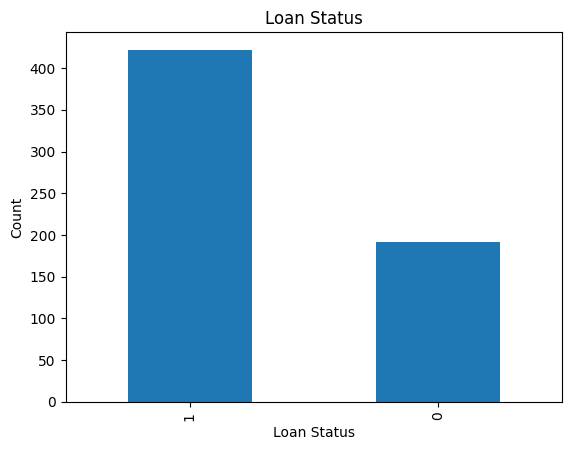

In [14]:
print(df["Loan_Status"].value_counts())

df["Loan_Status"].value_counts().plot(kind="bar")

plt.title("Loan Status")

plt.xlabel("Loan Status")

plt.ylabel("Count")

plt.show()

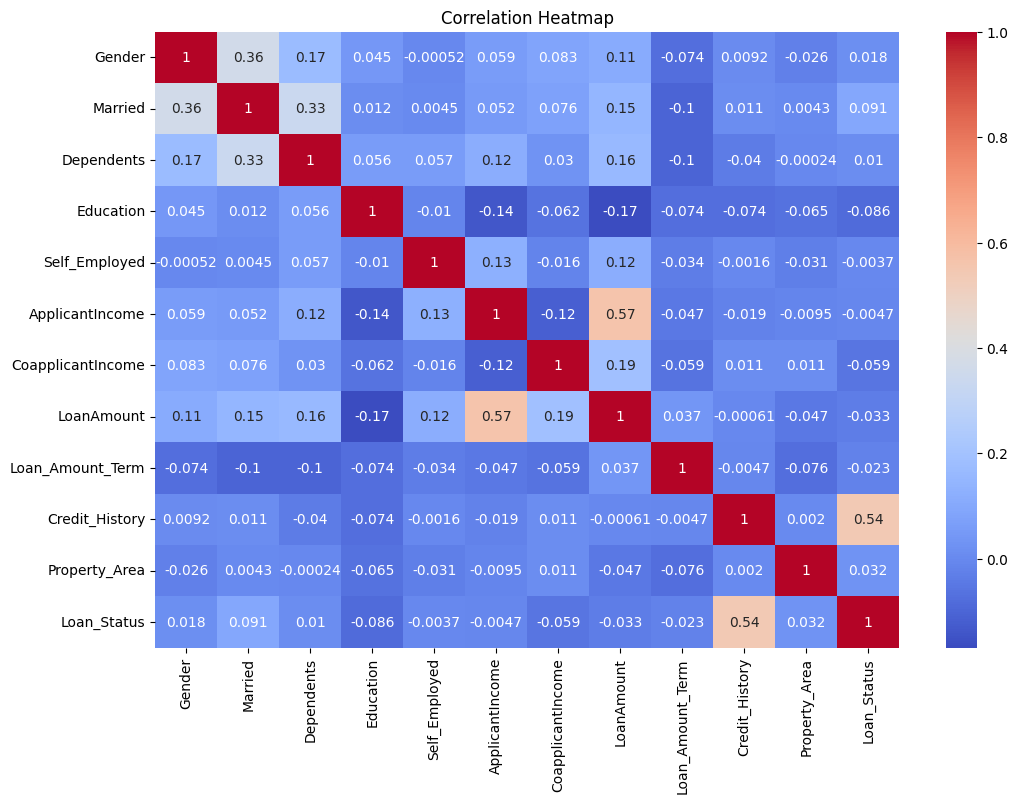

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [16]:
X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
y_pred = model.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.7560975609756098


[[18 25]
 [ 5 75]]


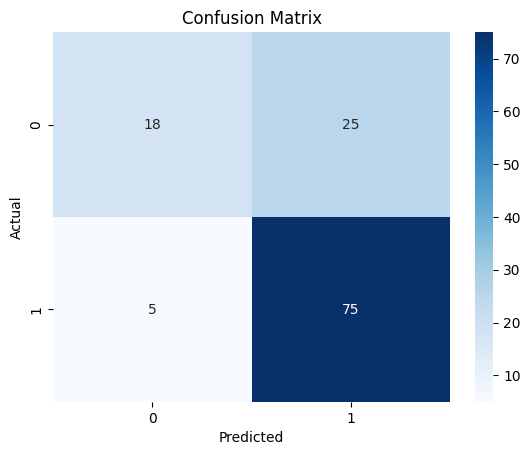

In [21]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



In [23]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

print(importance)

Credit_History       0.262914
ApplicantIncome      0.202666
LoanAmount           0.185022
CoapplicantIncome    0.113861
Loan_Amount_Term     0.051443
Property_Area        0.049602
Dependents           0.048141
Married              0.023648
Education            0.021271
Gender               0.020718
Self_Employed        0.020713
dtype: float64


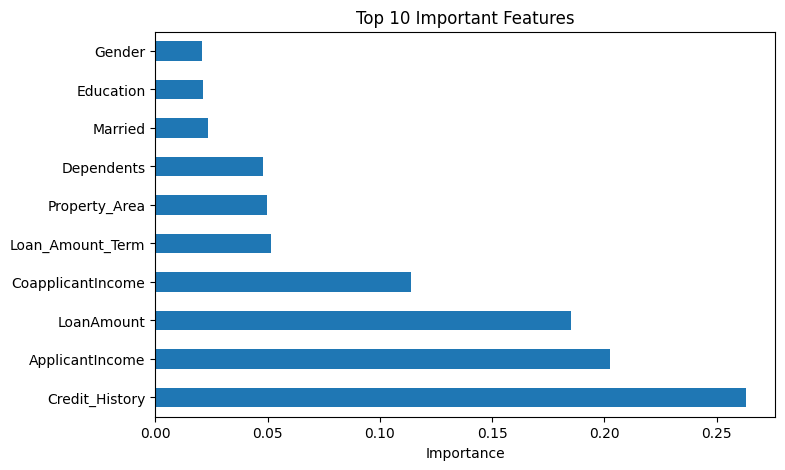

In [24]:
importance.head(10).plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.show()

In [25]:
print("Average Applicant Income")

print(df["ApplicantIncome"].mean())

print()

print("Average Loan Amount")

print(df["LoanAmount"].mean())

print()

print("Loan Status Counts")

print(df["Loan_Status"].value_counts())

Average Applicant Income
5403.459283387622

Average Loan Amount
145.75244299674267

Loan Status Counts
Loan_Status
1    422
0    192
Name: count, dtype: int64


In [26]:
print("Model Performance")

print("---------------------")

print("Accuracy :", accuracy)

print()

print(classification_report(y_test, y_pred))

Model Performance
---------------------
Accuracy : 0.7560975609756098

              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123

